# Сравнение длительности прослушивания книг читателями из Москвы и Санкт-Петербурга

- Автор: Березинский Вадим Сергеевич
- Дата: 26.06.2025

## Цели и задачи проекта

**Цель исследования:** проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении Яндекс.Книги, чем пользователи из Москвы.

**Задачи:**
1. Провести предобработку данных.
2. Проверить гипотезу.
3. Сформулировать выводы по проведённому анализу.

## Описание данных

Анализ проводится на основе данных приложения Яндекс.Книги за сентябрь - декабрь 2024 года о пользователях из Москвы и Санкт-Петербурга. 

Данные представлены в таблице `yandex_knigi_data.csv`, содержащей следующие поля:

- `city` - данные о городе пользователя (Москва или Санкт-Петербург);
- `puid` - id пользователя;
- `hours` - количество часов активности (чтения/прослушивания книг)

## Содержимое проекта

План работы:
    
    1. Подготовка и проверка данных
    2. Выбор статистического теста
    3. Проверка гипотезы с помощью выбранного статистического теста
    4. Интерпретация результата и формулирование выводов и рекомендаций

---

## 1. Загрузка данных и знакомство с ними

In [6]:
# Импортируем pandas для работы с данными:

import pandas as pd

# Импортируем библиотеки для визуализации:

import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеки для статистических расчетов
import scipy.stats as st
import numpy as np

# Импортируем библиотеку для проведения теста Левене:

from scipy.stats import levene

In [7]:
# Выгрузим данные из csv-файла в датафрейм:

df=pd.read_csv('yandex_knigi_data.csv')

# Осмотрим данные:

display(df.head(), df.info(),df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


None

,Unnamed: 0,puid,hours
count,8784.000000,8.784000e+03,8784.000000
mean,4391.500000,1.029234e+13,11.087670
std,2535.866716,1.073532e+14,37.701350
min,0.000000,9.668000e+03,0.000018
25%,2195.750000,3.239271e+08,0.066246
50%,4391.500000,8.828218e+08,0.942344
75%,6587.250000,1.516464e+09,6.065151
max,8783.000000,1.130000e+15,978.764775


Мы видим таблицу, которая, вопреки ожиданиям состоит из четырех столбцов, столбец `Unnamed: 0` содержит нумерацию строк, дублирует значения индекса и является избыточным для анализа, его можно удалить из датафрейма.

Наименования столбцов корректные и не требуют обработки.

Типы данных в столбцах `city`, `puid`, `hours` соответствуют хранимым данным и не требуют преобразования.

Таблица содержит 8784 строки, все столбцы заполнены без пропусков.

## Предобработка данных

In [10]:
# Удалим лишний столбец из датафрейма:

df=df.drop('Unnamed: 0',axis=1)
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [11]:
# Проверим данные на дубликаты:

df.duplicated(subset='puid').sum()

244

In [12]:
# Удалим явные дубликаты:

df=df.drop_duplicates(subset='puid')

df.duplicated(subset='puid').sum()

0

In [13]:
# Проверим, что в столбце city только нужные нам города:

df['city'].unique()

array(['Москва', 'Санкт-Петербург'], dtype=object)

In [14]:
display(df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8540 non-null   object 
 1   puid    8540 non-null   int64  
 2   hours   8540 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 266.9+ KB


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


None

#### Предварительный вывод

Итак, после предобработки мы выявили и удалили из датафрейма 244 строки-дубликата по id пользователей, удалили не нужный для анализа столбец `Unnamed: 0` и проверили, что таблица содержит данные только по Москве и Санкт-Петербургу.

Итоговый датафрейм состоит из трех столбцов и 8540 уникальных строк

## Сравнение размера выборок, их статистик и распределение

Перед проверкой гипотезы сформируем две группы, сравни их размеры, статистики и распределение.

In [17]:
# Сформируем две выборки:

moscow = df[df['city']=='Москва']['hours']

spb = df[df['city']=='Санкт-Петербург']['hours']

In [18]:
# Сравним размеры выборок:

display(f'Количество пользователей в Москве:{len(moscow)}')
display(f'Количество пользователей в Санкт-Петербурге:{len(spb)}')

'Количество пользователей в Москве:6234'

'Количество пользователей в Санкт-Петербурге:2306'

Мы видим, что выборка по Москве почти в три раза больше выборки по СПб. Разница в размерах снижает мощность статистических тестов, неравные размеры усиливают влияние различий в дисперсиях групп на результаты тестов, большая выборка из Москвы может доминировать в анализах, маскируя особенности СПб.

Тем не менее, если выборки отличны по размеру более чем на 25%, можно применить `ttest` с поправкой Уэлча, предварительно проверив и удалив выбросы в данных.

Проверим, что пользователи из Москвы и Санкт-Петербурга не пересекаются.

In [22]:
# Зададим множество пользователей из Москвы:

moscow_group = set(df[df['city']=='Москва']['puid'])

# Зададим множество пользователей из Санкт-Петербурга:

spb_group = set(df[df['city']=='Санкт-Петербург']['puid'])

# Найдем пересечение множеств:

intersection = moscow_group.intersection(spb_group)

if intersection == set():
    display('Пользователи из Москвы и Санкт-Петербурга не пересекаются.')
else:
    display(f'Пользователи из Москвы и Санкт-Петербурга включают одинаковых пользователей:{intersection}')

'Пользователи из Москвы и Санкт-Петербурга не пересекаются.'

Теперь проверим однородность дисперсий в двух выборках с помощью теста Левене.

In [24]:
# Проверяем однородность дисперсий в двух выборках с помощью теста Левене:

stat, p_value = levene(moscow, spb)
print(f"Статистика теста Левене: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Задаем уровень значимости:

alpha = 0.05

# Интерпретируем результат:

if p_value < alpha:
    print("Отклоняем гипотезу о равенстве дисперсий — дисперсии различаются")
else:
    print("Принимаем гипотезу о равенстве дисперсий — дисперсии однородны")

Статистика теста Левене: 0.1841
p-value: 0.6679
Принимаем гипотезу о равенстве дисперсий — дисперсии однородны


Таким образом, дисперсии в выборках пользователей из Москвы и Санкт-Петербурга однородны.

Теперь проверим распределение в выборках.

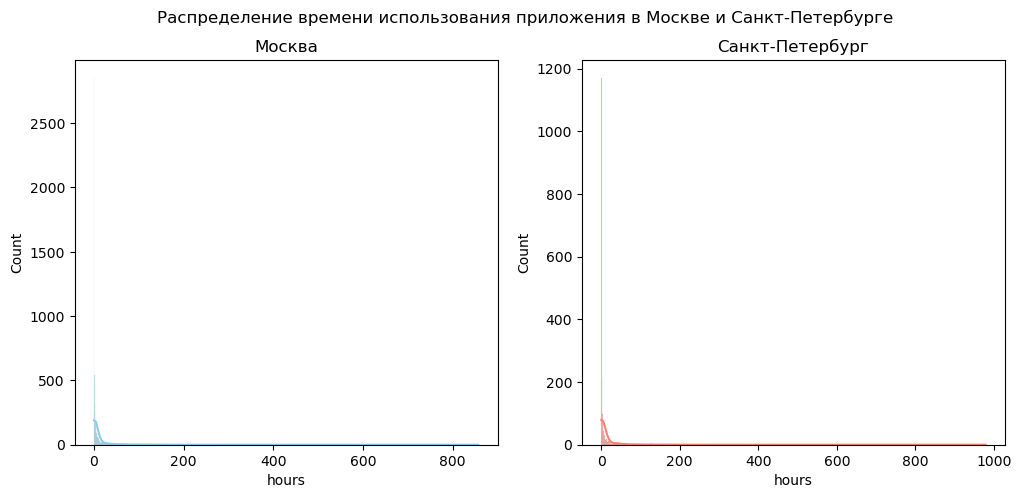

In [26]:
# Визуализируем распределения времени использования приложения для Москвы и Санкт-Петербурга:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Строим гистограмму для выборки moscow с KDE:
sns.histplot(moscow, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Москва')

# Строим гистограмму для выборки spb с KDE:

sns.histplot(spb, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Санкт-Петербург')

# Задаем заголовок
plt.suptitle('Распределение времени использования приложения в Москве и Санкт-Петербурге')
plt.show()

Мы видим, что гистограммы распределения времени использования приложения в Москве и Санкт-Петербурге похожи, но распределение не является нормальным.

In [28]:
# Очистим выборки от выбросов методом межквартильного размаха:

# 1. Вычисляем Q1 и Q3
Q1 = moscow.quantile(0.25)
Q3 = moscow.quantile(0.75)

# 2. Вычисляем IQR
IQR = Q3 - Q1

# 3. Определяем границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Фильтруем выборку, оставляя только значения без выбросов
moscow_clean = moscow[(moscow >= lower_bound) & (moscow <= upper_bound)]

# 1. Вычисляем Q1 и Q3
Q1 = spb.quantile(0.25)
Q3 = spb.quantile(0.75)

# 2. Вычисляем IQR
IQR = Q3 - Q1

# 3. Определяем границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Фильтруем выборку, оставляя только значения без выбросов
spb_clean = spb[(spb >= lower_bound) & (spb <= upper_bound)]

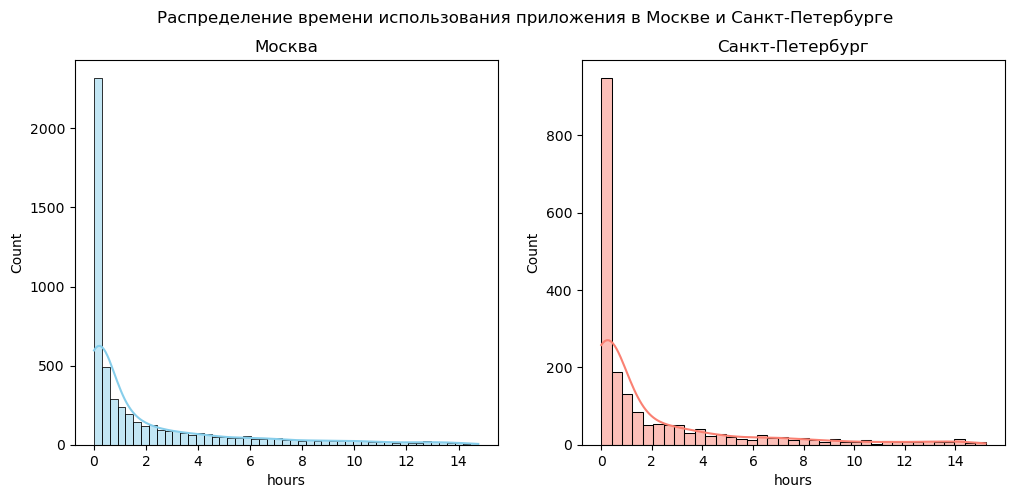

In [29]:
# Визуализируем распределения времени использования приложения для Москвы и Санкт-Петербурга:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Строим гистограмму для выборки moscow с KDE:
sns.histplot(moscow_clean, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Москва')

# Строим гистограмму для выборки spb с KDE:

sns.histplot(spb_clean, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Санкт-Петербург')

# Задаем заголовок
plt.suptitle('Распределение времени использования приложения в Москве и Санкт-Петербурге')
plt.show()

#### Промежуточный вывод

Итак, мы выяснили, что выборка по Москве почти в три раза больше выборки по СПб. Тем не менее, если выборки отличны по размеру более чем на 25%, можно применить `ttest` с поправкой Уэлча, предварительно проверив и удалив выбросы в данных.

Выборки являются независимыми - пользователи в двух выборках не пересекаются между собой.

По результатам проверки тестом Левена установлено, что дисперсии в выборках пользователей из Москвы и Санкт-Петербурга однородны.

По результатам проверки с помощью визуализации гистограмм установлено, что распределение в выборках по Москве и Санкт-Петербургу не является нормальным.

С помощью метода межквартильного размаха выборки были очищены от выбросов.

Исходя из этих предпосылок, поскольку распределения не нормальные, классический t-тест Стьюдента применять не стоит, но, поскольку мы очистили выборки от выбросов, можно применить `ttest` с поправкой Уэлча.

## Проверка гипотезы в Python

Проверим, проводят ли пользователи из Санкт-Петербурга в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

Действовать будем по алгоритму проверки гипотез:

**1. Определяем тип гипотезы.** Нам необходимо проверить, что средняя активность пользователей в Санкт-Петербурге больше, то есть альтернативная гипотеза является односторонней, а именно правосторонней, поскольку нас интересует отклонение в большую сторону. 

**2. Формулируем нулевую и альтернативную гипотезы.**

Нулевая гипотеза(Н0): Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

Альтернативная гипотеза (Н1): Средняя активность пользователей в Санкт-Петербурге больше.

**3. Выбираем уровень значимости α**
Поскольку ситуация обычная и не требует повышенной осторожности, то выбираем уровень значимости α = 0.05

**4. Выбираем статистический тест для проверки гипотезы.** поскольку распределения не нормальные, классический t-тест Стьюдента применять не стоит, но, поскольку мы очистили выборки от выбросов, можно применить `ttest` с поправкой Уэлча.

In [33]:
# Запишем в переменную выбранное значение уровня значимости:

alpha = 0.05

# Применяем t-тест с поправкой Уэлча:

results = st.ttest_ind(moscow_clean,spb_clean,alternative='less', equal_var=False)

# Выведем р-значение:

print('p-значение:',results.pvalue)

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: пользователи СПб проводят в среднем больше времени в приложении.")
else:
    print("Нет оснований отвергать нулевую гипотезу.")


p-значение: 0.6430387188079352
Нет оснований отвергать нулевую гипотезу.


## Аналитическая записка

Целью исследования была проверка гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении Яндекс.Книги, чем пользователи из Москвы.

Мы проверили выборки на независимость - пользователи в двух выборках не пересекаются между собой.

По результатам проверки тестом Левена установлено, что дисперсии в выборках пользователей из Москвы и Санкт-Петербурга однородны.

По результатам проверки с помощью визуализации гистограмм установлено, что распределение в выборках по Москве и Санкт-Петербургу не является нормальным.

С помощью метода межквартильного размаха выборки были очищены от выбросов.

Исходя из этих предпосылок, поскольку распределения не нормальные, классический t-тест Стьюдента применять не стоит, но, поскольку мы очистили выборки от выбросов, для проверки гипотезы применили `ttest` с поправкой Уэлча.

Гипотезы были сформулированы следующим образом:

    - Нулевая гипотеза(Н0): Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

    - Альтернативная гипотеза (Н1): Средняя активность пользователей в Санкт-Петербурге больше.
    
Гипотеза была проверена с помощью `ttest` с поправкой Уэлча. В результате мы получили p-значение: 0.6430.

Значение p-value оказалось больше выбранного уровня значимости, что можно интерпретировать так: при верности нулевой гипотезы вероятность получить наблюдемые значения составляет 64%, что не позволяет нам отвергнуть нулевую гипотезу.

У нас не получилось статистически доказать, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении Яндекс.Книги, чем пользователи из Москвы. Полученный результат можно объяснить тем, что пользовательское поведение и привычки жителей Москвы и Санкт-Петербурга схожи.